Data Pre-processing :

The primary goal is to get further insight into the data

In [75]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [76]:
data=pd.read_csv('train.csv')
data.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


Data leaks are inevitable, hence we must first divide the data before applying the feature.

In [77]:
X_train,X_test,y_train,y_test=train_test_split(data,data['SalePrice'],test_size=0.1,random_state=0)

In [78]:
X_train.shape, X_test.shape

((1314, 81), (146, 81))

Handle missing values

In [79]:
## Collect all of the nan values 
## Start by addressing the missing categorical characteristics
features_nan=[feature for feature in data.columns if data[feature].isnull().sum()>1 and data[feature].dtypes=='O']

for feature in features_nan:
    print("{}: {}% missing values".format(feature,np.round(data[feature].isnull().mean(),4)))

Alley: 0.9377% missing values
MasVnrType: 0.5973% missing values
BsmtQual: 0.0253% missing values
BsmtCond: 0.0253% missing values
BsmtExposure: 0.026% missing values
BsmtFinType1: 0.0253% missing values
BsmtFinType2: 0.026% missing values
FireplaceQu: 0.4726% missing values
GarageType: 0.0555% missing values
GarageFinish: 0.0555% missing values
GarageQual: 0.0555% missing values
GarageCond: 0.0555% missing values
PoolQC: 0.9952% missing values
Fence: 0.8075% missing values
MiscFeature: 0.963% missing values


In [80]:
## Replace missing value with a new label
def replace_cat_feature(data,features_nan):
    data=data.copy()
    data[features_nan]=data[features_nan].fillna('Missing')
    return data

data=replace_cat_feature(data,features_nan)

data[features_nan].isnull().sum()

Alley           0
MasVnrType      0
BsmtQual        0
BsmtCond        0
BsmtExposure    0
BsmtFinType1    0
BsmtFinType2    0
FireplaceQu     0
GarageType      0
GarageFinish    0
GarageQual      0
GarageCond      0
PoolQC          0
Fence           0
MiscFeature     0
dtype: int64

In [81]:
data.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,Missing,Reg,Lvl,AllPub,...,0,Missing,Missing,Missing,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,Missing,Reg,Lvl,AllPub,...,0,Missing,Missing,Missing,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,Missing,IR1,Lvl,AllPub,...,0,Missing,Missing,Missing,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,Missing,IR1,Lvl,AllPub,...,0,Missing,Missing,Missing,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,Missing,IR1,Lvl,AllPub,...,0,Missing,Missing,Missing,0,12,2008,WD,Normal,250000


In [82]:
## Now lets check for numerical variables the contains missing values
numerical_with_nan=[feature for feature in data.columns if data[feature].isnull().sum()>1 and data[feature].dtypes!='O']

## We will print the numerical nan variables and percentage of missing values

for feature in numerical_with_nan:
    print("{}: {}% missing value".format(feature,np.around(data[feature].isnull().mean(),4)))

LotFrontage: 0.1774% missing value
MasVnrArea: 0.0055% missing value
GarageYrBlt: 0.0555% missing value


In [83]:
## Replacing the numerical Missing Values

for feature in numerical_with_nan:
    ## We will replace by using median since there are outliers
    median_value=data[feature].median()
    
    ## create a new feature to capture nan values
    data[feature+'nan']=np.where(data[feature].isnull(),1,0)
    data[feature].fillna(median_value,inplace=True)
    
data[numerical_with_nan].isnull().sum()

LotFrontage    0
MasVnrArea     0
GarageYrBlt    0
dtype: int64

In [84]:
data.head(30)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice,LotFrontagenan,MasVnrAreanan,GarageYrBltnan
0,1,60,RL,65.0,8450,Pave,Missing,Reg,Lvl,AllPub,...,Missing,0,2,2008,WD,Normal,208500,0,0,0
1,2,20,RL,80.0,9600,Pave,Missing,Reg,Lvl,AllPub,...,Missing,0,5,2007,WD,Normal,181500,0,0,0
2,3,60,RL,68.0,11250,Pave,Missing,IR1,Lvl,AllPub,...,Missing,0,9,2008,WD,Normal,223500,0,0,0
3,4,70,RL,60.0,9550,Pave,Missing,IR1,Lvl,AllPub,...,Missing,0,2,2006,WD,Abnorml,140000,0,0,0
4,5,60,RL,84.0,14260,Pave,Missing,IR1,Lvl,AllPub,...,Missing,0,12,2008,WD,Normal,250000,0,0,0
5,6,50,RL,85.0,14115,Pave,Missing,IR1,Lvl,AllPub,...,Shed,700,10,2009,WD,Normal,143000,0,0,0
6,7,20,RL,75.0,10084,Pave,Missing,Reg,Lvl,AllPub,...,Missing,0,8,2007,WD,Normal,307000,0,0,0
7,8,60,RL,69.0,10382,Pave,Missing,IR1,Lvl,AllPub,...,Shed,350,11,2009,WD,Normal,200000,1,0,0
8,9,50,RM,51.0,6120,Pave,Missing,Reg,Lvl,AllPub,...,Missing,0,4,2008,WD,Abnorml,129900,0,0,0
9,10,190,RL,50.0,7420,Pave,Missing,Reg,Lvl,AllPub,...,Missing,0,1,2008,WD,Normal,118000,0,0,0


In [85]:
## Temporal Factors (Time-Based Factors)
for feature in ['YearBuilt','YearRemodAdd','GarageYrBlt']:
       
    data[feature]=data['YrSold']-data[feature]

In [86]:
data.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice,LotFrontagenan,MasVnrAreanan,GarageYrBltnan
0,1,60,RL,65.0,8450,Pave,Missing,Reg,Lvl,AllPub,...,Missing,0,2,2008,WD,Normal,208500,0,0,0
1,2,20,RL,80.0,9600,Pave,Missing,Reg,Lvl,AllPub,...,Missing,0,5,2007,WD,Normal,181500,0,0,0
2,3,60,RL,68.0,11250,Pave,Missing,IR1,Lvl,AllPub,...,Missing,0,9,2008,WD,Normal,223500,0,0,0
3,4,70,RL,60.0,9550,Pave,Missing,IR1,Lvl,AllPub,...,Missing,0,2,2006,WD,Abnorml,140000,0,0,0
4,5,60,RL,84.0,14260,Pave,Missing,IR1,Lvl,AllPub,...,Missing,0,12,2008,WD,Normal,250000,0,0,0


In [87]:
data[['YearBuilt','YearRemodAdd','GarageYrBlt']].head()

,YearBuilt,YearRemodAdd,GarageYrBlt
0,5,5,5.0
1,31,31,31.0
2,7,6,7.0
3,91,36,8.0
4,8,8,8.0


Perform data normalization:
Means was how we handled missing values in the past. We will now also employ a log-normal distribution as the variables may exhibit skewness.

In [88]:
data.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice,LotFrontagenan,MasVnrAreanan,GarageYrBltnan
0,1,60,RL,65.0,8450,Pave,Missing,Reg,Lvl,AllPub,...,Missing,0,2,2008,WD,Normal,208500,0,0,0
1,2,20,RL,80.0,9600,Pave,Missing,Reg,Lvl,AllPub,...,Missing,0,5,2007,WD,Normal,181500,0,0,0
2,3,60,RL,68.0,11250,Pave,Missing,IR1,Lvl,AllPub,...,Missing,0,9,2008,WD,Normal,223500,0,0,0
3,4,70,RL,60.0,9550,Pave,Missing,IR1,Lvl,AllPub,...,Missing,0,2,2006,WD,Abnorml,140000,0,0,0
4,5,60,RL,84.0,14260,Pave,Missing,IR1,Lvl,AllPub,...,Missing,0,12,2008,WD,Normal,250000,0,0,0


In [89]:
num_features=['LotFrontage', 'LotArea', '1stFlrSF', 'GrLivArea', 'SalePrice']

for feature in num_features:
    data[feature]=np.log(data[feature])

In [90]:
data.head(50)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice,LotFrontagenan,MasVnrAreanan,GarageYrBltnan
0,1,60,RL,4.174387,9.041922,Pave,Missing,Reg,Lvl,AllPub,...,Missing,0,2,2008,WD,Normal,12.247694,0,0,0
1,2,20,RL,4.382027,9.169518,Pave,Missing,Reg,Lvl,AllPub,...,Missing,0,5,2007,WD,Normal,12.109011,0,0,0
2,3,60,RL,4.219508,9.328123,Pave,Missing,IR1,Lvl,AllPub,...,Missing,0,9,2008,WD,Normal,12.317167,0,0,0
3,4,70,RL,4.094345,9.164296,Pave,Missing,IR1,Lvl,AllPub,...,Missing,0,2,2006,WD,Abnorml,11.849398,0,0,0
4,5,60,RL,4.430817,9.565214,Pave,Missing,IR1,Lvl,AllPub,...,Missing,0,12,2008,WD,Normal,12.429216,0,0,0
5,6,50,RL,4.442651,9.554993,Pave,Missing,IR1,Lvl,AllPub,...,Shed,700,10,2009,WD,Normal,11.870600,0,0,0
6,7,20,RL,4.317488,9.218705,Pave,Missing,Reg,Lvl,AllPub,...,Missing,0,8,2007,WD,Normal,12.634603,0,0,0
7,8,60,RL,4.234107,9.247829,Pave,Missing,IR1,Lvl,AllPub,...,Shed,350,11,2009,WD,Normal,12.206073,1,0,0
8,9,50,RM,3.931826,8.719317,Pave,Missing,Reg,Lvl,AllPub,...,Missing,0,4,2008,WD,Abnorml,11.774520,0,0,0
9,10,190,RL,3.912023,8.911934,Pave,Missing,Reg,Lvl,AllPub,...,Missing,0,1,2008,WD,Normal,11.678440,0,0,0


Encode categorical variables

After the data has been standardized, we see that it comes in two primary formats: character and numeric. We convert the textual data to numeric data based on data_description in order to use Label Encoding to homogenize the data.

In [91]:
non_numeric_columns = data.select_dtypes(exclude='number').columns
non_numeric_columns
content = []
with open('data_description.txt', 'r') as file:
    text = file.read().split('\n')
    for line in text:
        if line.strip():
            if not line.startswith('\t'):
                content.append(line.split('\t')[0].strip())

result_dict = {}
current_key = None
for item in content:
    if ':' in item:
        count = 1
        current_key = item[:-1].split(':')[0]
        result_dict[current_key] = []
    elif current_key is not None:
        result_dict[current_key].append(item)
        result_dict[current_key].append(count)
        count += 1

for i in non_numeric_columns:
    print(result_dict[i])

for i in non_numeric_columns:
    new_values = result_dict[i]
    value_mapping = dict(zip(new_values[::2], new_values[1::2]))
    data[i] = data[i].map(value_mapping)


['A', 1, 'C', 2, 'FV', 3, 'I', 4, 'RH', 5, 'RL', 6, 'RP', 7, 'RM', 8]
['Grvl', 1, 'Pave', 2]
['Grvl', 1, 'Pave', 2, 'NA', 3]
['Reg', 1, 'IR1', 2, 'IR2', 3, 'IR3', 4]
['Lvl', 1, 'Bnk', 2, 'HLS', 3, 'Low', 4]
['AllPub', 1, 'NoSewr', 2, 'NoSeWa', 3, 'ELO', 4]
['Inside', 1, 'Corner', 2, 'CulDSac', 3, 'FR2', 4, 'FR3', 5]
['Gtl', 1, 'Mod', 2, 'Sev', 3]
['Blmngtn', 1, 'Blueste', 2, 'BrDale', 3, 'BrkSide', 4, 'ClearCr', 5, 'CollgCr', 6, 'Crawfor', 7, 'Edwards', 8, 'Gilbert', 9, 'IDOTRR', 10, 'MeadowV', 11, 'Mitchel', 12, 'Names', 13, 'NoRidge', 14, 'NPkVill', 15, 'NridgHt', 16, 'NWAmes', 17, 'OldTown', 18, 'SWISU', 19, 'Sawyer', 20, 'SawyerW', 21, 'Somerst', 22, 'StoneBr', 23, 'Timber', 24, 'Veenker', 25]
['Artery', 1, 'Feedr', 2, 'Norm', 3, 'RRNn', 4, 'RRAn', 5, 'PosN', 6, 'PosA', 7, 'RRNe', 8, 'RRAe', 9]
['Artery', 1, 'Feedr', 2, 'Norm', 3, 'RRNn', 4, 'RRAn', 5, 'PosN', 6, 'PosA', 7, 'RRNe', 8, 'RRAe', 9]
['1Fam', 1, '2FmCon', 2, 'Duplx', 3, 'TwnhsE', 4, 'TwnhsI', 5]
['1Story', 1, '1.5Fin', 

In [92]:
data.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice,LotFrontagenan,MasVnrAreanan,GarageYrBltnan
0,1,60,6.0,4.174387,9.041922,2,NaN,1,1,1,...,NaN,0,2,2008,1,1,12.247694,0,0,0
1,2,20,6.0,4.382027,9.169518,2,NaN,1,1,1,...,NaN,0,5,2007,1,1,12.109011,0,0,0
2,3,60,6.0,4.219508,9.328123,2,NaN,2,1,1,...,NaN,0,9,2008,1,1,12.317167,0,0,0
3,4,70,6.0,4.094345,9.164296,2,NaN,2,1,1,...,NaN,0,2,2006,1,2,11.849398,0,0,0
4,5,60,6.0,4.430817,9.565214,2,NaN,2,1,1,...,NaN,0,12,2008,1,1,12.429216,0,0,0


Remove duplicates and remove missing values:

We see that the values we have seem to be duplicates and NaN when labeling variable values based on data_description. Thus, processing the data requires one more step.

In [93]:
threshold = 1
data = data.dropna(axis=1, thresh=len(data) - threshold + 1)

In [94]:
data = data.drop_duplicates()

In [95]:
data.head()

,Id,MSSubClass,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,...,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice,LotFrontagenan,MasVnrAreanan,GarageYrBltnan
0,1,60,4.174387,9.041922,2,1,1,1,1,1,...,0,0,2,2008,1,1,12.247694,0,0,0
1,2,20,4.382027,9.169518,2,1,1,1,4,1,...,0,0,5,2007,1,1,12.109011,0,0,0
2,3,60,4.219508,9.328123,2,2,1,1,1,1,...,0,0,9,2008,1,1,12.317167,0,0,0
3,4,70,4.094345,9.164296,2,2,1,1,2,1,...,0,0,2,2006,1,2,11.849398,0,0,0
4,5,60,4.430817,9.565214,2,2,1,1,4,1,...,0,0,12,2008,1,1,12.429216,0,0,0


After processing the Data Pre-processing we saved the file and moved on to the Exploratory data analysis (EDA) phase.

In [96]:
data.to_csv('Exploratory Data Analysis.csv',index=False)

Exploratory Data Analysis (EDA)

In [97]:
data=pd.read_csv('Exploratory Data Analysis.csv')
data.head()

,Id,MSSubClass,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,...,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice,LotFrontagenan,MasVnrAreanan,GarageYrBltnan
0,1,60,4.174387,9.041922,2,1,1,1,1,1,...,0,0,2,2008,1,1,12.247694,0,0,0
1,2,20,4.382027,9.169518,2,1,1,1,4,1,...,0,0,5,2007,1,1,12.109011,0,0,0
2,3,60,4.219508,9.328123,2,2,1,1,1,1,...,0,0,9,2008,1,1,12.317167,0,0,0
3,4,70,4.094345,9.164296,2,2,1,1,2,1,...,0,0,2,2006,1,2,11.849398,0,0,0
4,5,60,4.430817,9.565214,2,2,1,1,4,1,...,0,0,12,2008,1,1,12.429216,0,0,0


Descriptive statistics for the entire DataFrame:

Descriptive statistics give an overview of the key elements of a dataset. That is a practical method of obtaining a broad overview of the distribution's shape, central tendency, and dispersion for each column's values.

In [98]:
data.describe()

,Id,MSSubClass,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,...,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice,LotFrontagenan,MasVnrAreanan,GarageYrBltnan
count,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,4.198687,9.110838,1.995890,1.408219,1.185616,1.001370,1.416438,1.062329,...,2.758904,43.489041,6.321918,2007.815753,1.490411,1.582192,12.024051,0.177397,0.005479,0.055479
std,421.610009,42.300571,0.320396,0.517448,0.063996,0.582296,0.606509,0.052342,0.773448,0.276232,...,40.177307,496.123024,2.703626,1.328095,1.368616,1.475209,0.399452,0.382135,0.073846,0.228992
min,1.000000,20.000000,3.044522,7.170120,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,0.000000,0.000000,1.000000,2006.000000,1.000000,1.000000,10.460242,0.000000,0.000000,0.000000
25%,365.750000,20.000000,4.094345,8.929766,2.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,0.000000,0.000000,5.000000,2007.000000,1.000000,1.000000,11.775097,0.000000,0.000000,0.000000
50%,730.500000,50.000000,4.234107,9.156781,2.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,0.000000,0.000000,6.000000,2008.000000,1.000000,1.000000,12.001505,0.000000,0.000000,0.000000
75%,1095.250000,70.000000,4.369448,9.358890,2.000000,2.000000,1.000000,1.000000,2.000000,1.000000,...,0.000000,0.000000,8.000000,2009.000000,1.000000,1.000000,12.273731,0.000000,0.000000,0.000000
max,1460.000000,190.000000,5.746203,12.279532,2.000000,4.000000,4.000000,3.000000,5.000000,3.000000,...,738.000000,15500.000000,12.000000,2010.000000,10.000000,6.000000,13.534473,1.000000,1.000000,1.000000


Descriptive statistics for a specific column:

It provides us with an overview of all the features of a variable, much like descriptive statistics for the ertire  dataframe.

In [99]:
data['LotArea'].describe()

count    1460.000000
mean        9.110838
std         0.517448
min         7.170120
25%         8.929766
50%         9.156781
75%         9.358890
max        12.279532
Name: LotArea, dtype: float64

The data was not standardized prior to data processing, which resulted in missing and character or numeric data. Following the standardization of fundamental data kinds into numerical values.For determining the essential features of the dataset and identifying any issues, such as missing values, the 'info' function is useful. It's a quick way to assess the overall structure of the DataFrame without displaying all of the details.

In [100]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 64 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Id              1460 non-null   int64  
 1   MSSubClass      1460 non-null   int64  
 2   LotFrontage     1460 non-null   float64
 3   LotArea         1460 non-null   float64
 4   Street          1460 non-null   int64  
 5   LotShape        1460 non-null   int64  
 6   LandContour     1460 non-null   int64  
 7   Utilities       1460 non-null   int64  
 8   LotConfig       1460 non-null   int64  
 9   LandSlope       1460 non-null   int64  
 10  Condition1      1460 non-null   int64  
 11  Condition2      1460 non-null   int64  
 12  HouseStyle      1460 non-null   int64  
 13  OverallQual     1460 non-null   int64  
 14  OverallCond     1460 non-null   int64  
 15  YearBuilt       1460 non-null   int64  
 16  YearRemodAdd    1460 non-null   int64  
 17  RoofStyle       1460 non-null   i

Numerical Variables

In [101]:
# list of numerical variables
numerical_features = [feature for feature in data.columns if data[feature].dtypes != 'O']

print('Number of numerical variables: ', len(numerical_features))

# visualise the numerical variables
data[numerical_features].head()

Number of numerical variables:  64


,Id,MSSubClass,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,...,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice,LotFrontagenan,MasVnrAreanan,GarageYrBltnan
0,1,60,4.174387,9.041922,2,1,1,1,1,1,...,0,0,2,2008,1,1,12.247694,0,0,0
1,2,20,4.382027,9.169518,2,1,1,1,4,1,...,0,0,5,2007,1,1,12.109011,0,0,0
2,3,60,4.219508,9.328123,2,2,1,1,1,1,...,0,0,9,2008,1,1,12.317167,0,0,0
3,4,70,4.094345,9.164296,2,2,1,1,2,1,...,0,0,2,2006,1,2,11.849398,0,0,0
4,5,60,4.430817,9.565214,2,2,1,1,4,1,...,0,0,12,2008,1,1,12.429216,0,0,0


Temporal Variables(Eg: Datetime Variables)

List of variables that contain year information

In [102]:
year_feature = [feature for feature in numerical_features if 'Yr' in feature or 'Year' in feature]

year_feature

['YearBuilt', 'YearRemodAdd', 'GarageYrBlt', 'YrSold', 'GarageYrBltnan']

The Temporal Datetime Variables will be examined now.
We'll investigate whether the year the house is sold and the sale price are related.

Text(0.5, 1.0, 'House Price vs YearSold')

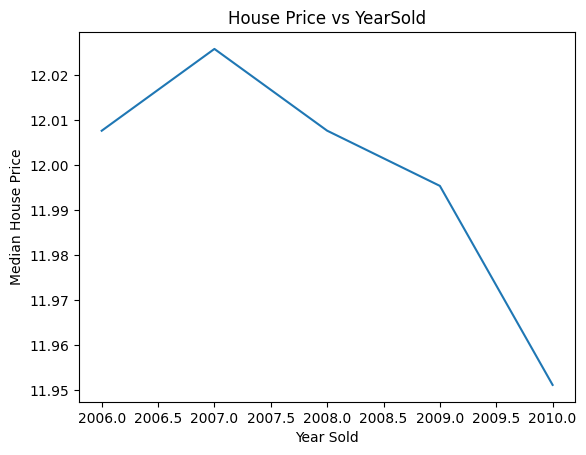

In [103]:
data.groupby('YrSold')['SalePrice'].median().plot()
plt.xlabel('Year Sold')
plt.ylabel('Median House Price')
plt.title("House Price vs YearSold")

Here, we'll contrast the variations between SalePrice and All Years Features.

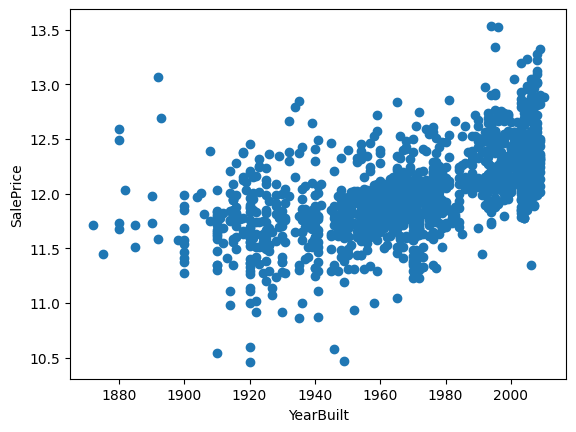

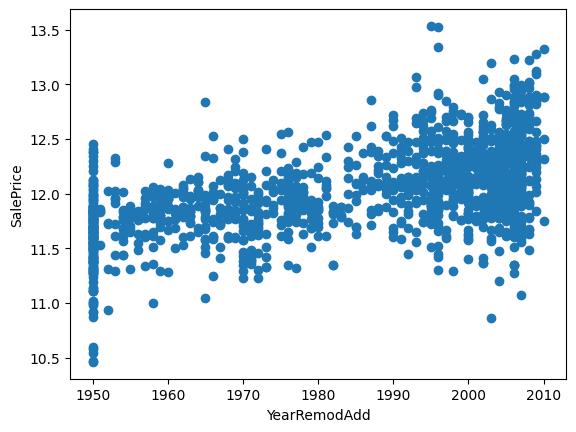

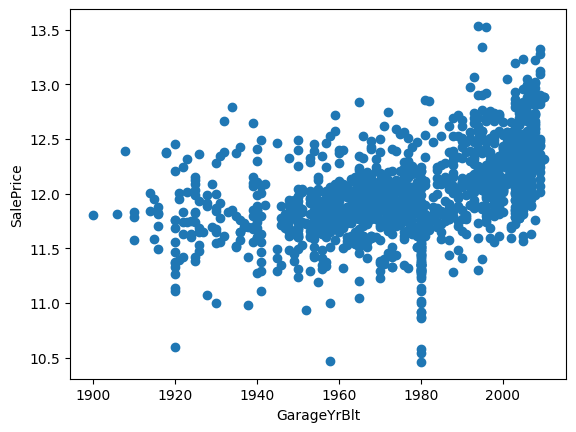

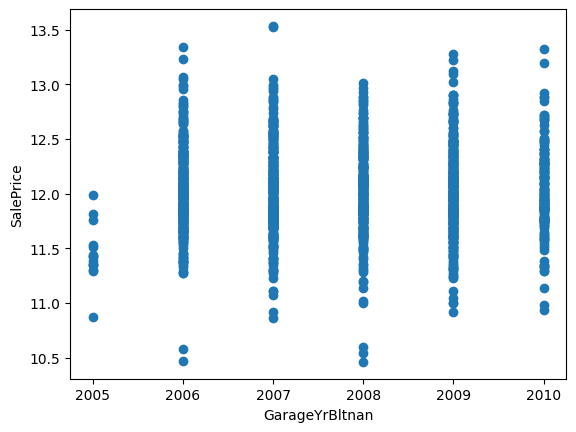

In [104]:
for feature in year_feature:
    if feature!='YrSold':
        data=data.copy()
        ## We will capture the difference between year variable and year the house was sold for
        data[feature]=data['YrSold']-data[feature]

        plt.scatter(data[feature],data['SalePrice'])
        plt.xlabel(feature)
        plt.ylabel('SalePrice')
        plt.show()

Numerical variables are usually of 2 type : Continous variable and Discrete Variables

Discrete Variables

In [105]:
discrete_feature=[feature for feature in numerical_features if len(data[feature].unique())<25 and feature not in year_feature+['Id']]
print("Discrete Variables Count: {}".format(len(discrete_feature)))

Discrete Variables Count: 42


In [106]:
data[discrete_feature].head()

,MSSubClass,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,Condition1,Condition2,HouseStyle,...,GarageCars,PavedDrive,3SsnPorch,PoolArea,MiscVal,MoSold,SaleType,SaleCondition,LotFrontagenan,MasVnrAreanan
0,60,2,1,1,1,1,1,3,3,4,...,2,1,0,0,0,2,1,1,0,0
1,20,2,1,1,1,4,1,2,3,1,...,2,1,0,0,0,5,1,1,0,0
2,60,2,2,1,1,1,1,3,3,4,...,2,1,0,0,0,9,1,1,0,0
3,70,2,2,1,1,2,1,3,3,4,...,3,1,0,0,0,2,1,2,0,0
4,60,2,2,1,1,4,1,3,3,4,...,3,1,0,0,0,12,1,1,0,0


Determine how they relate to Sale Price.

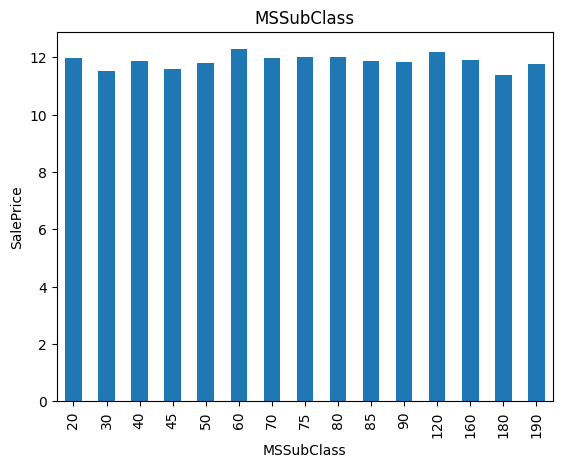

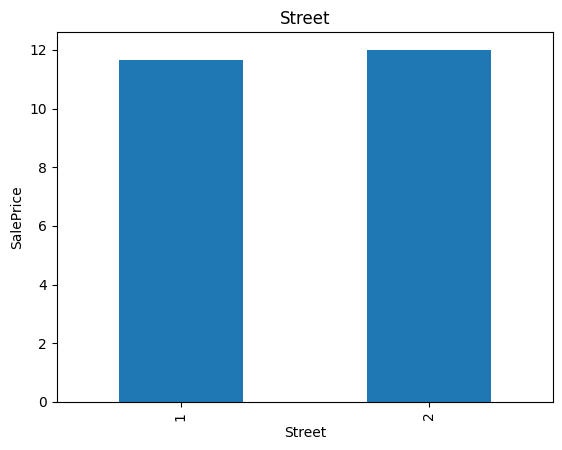

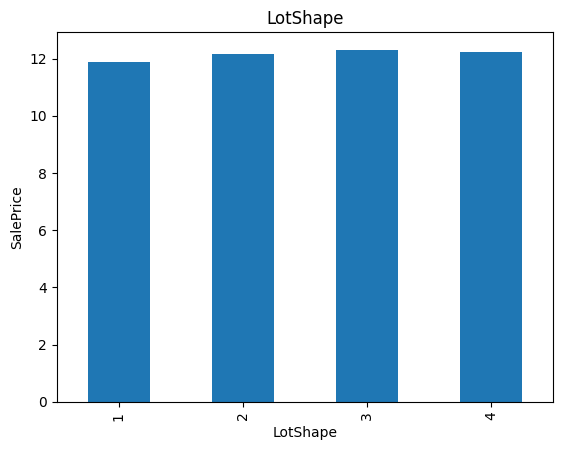

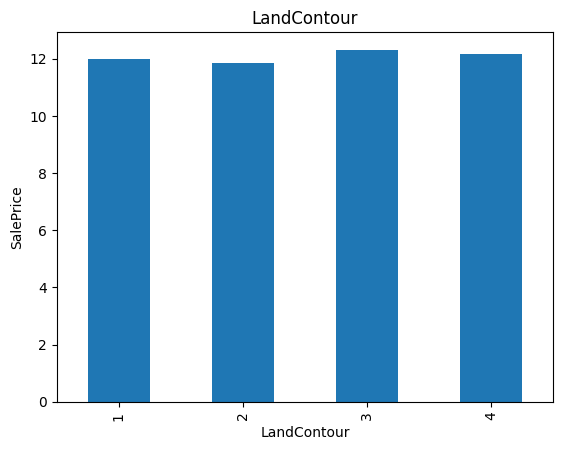

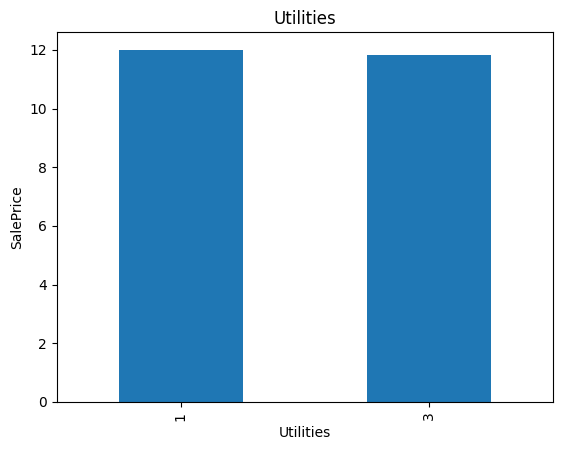

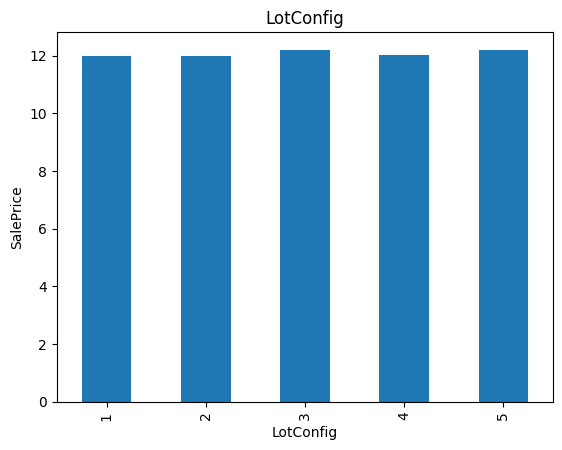

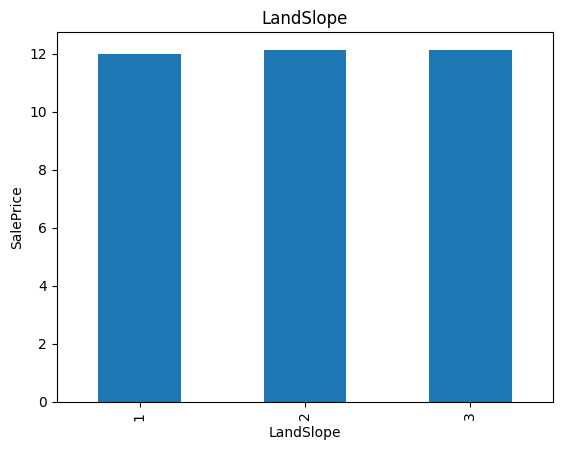

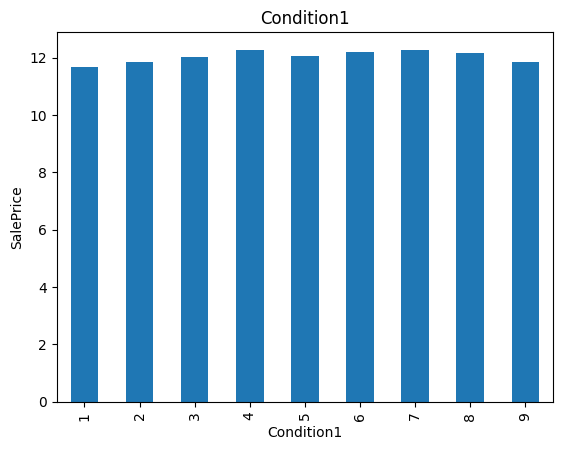

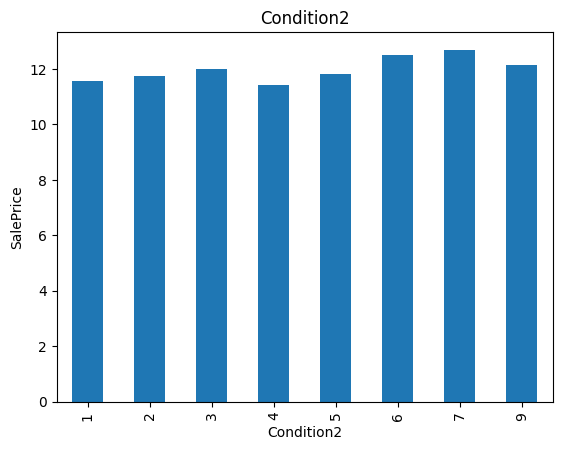

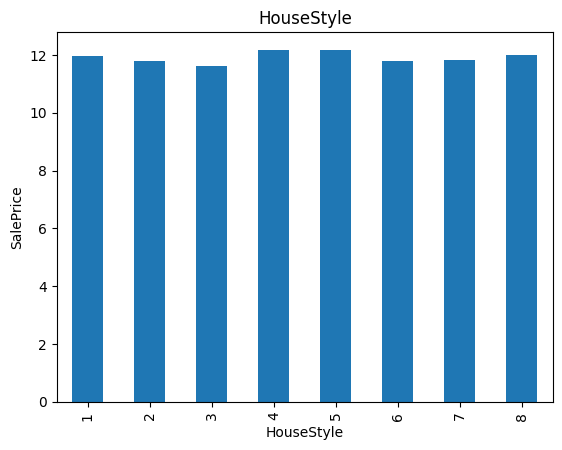

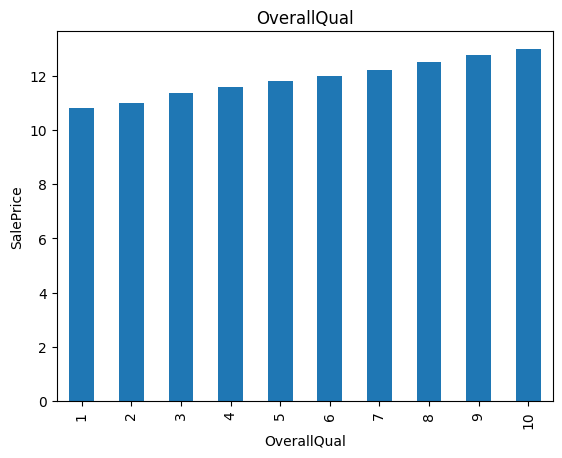

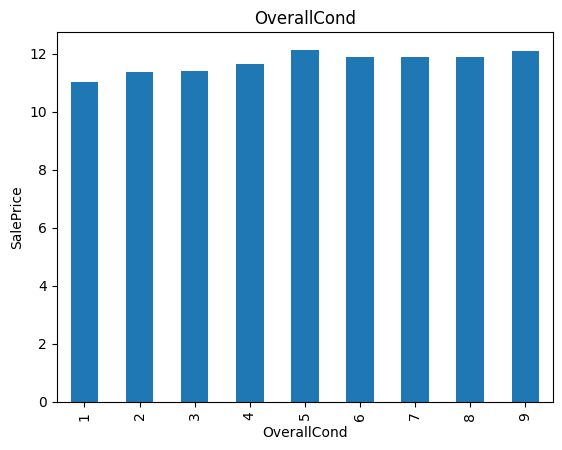

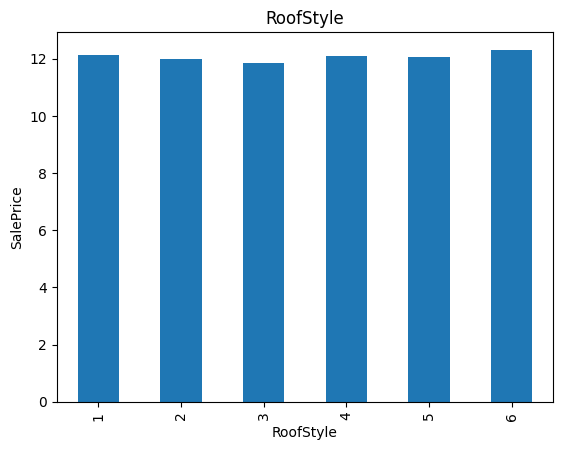

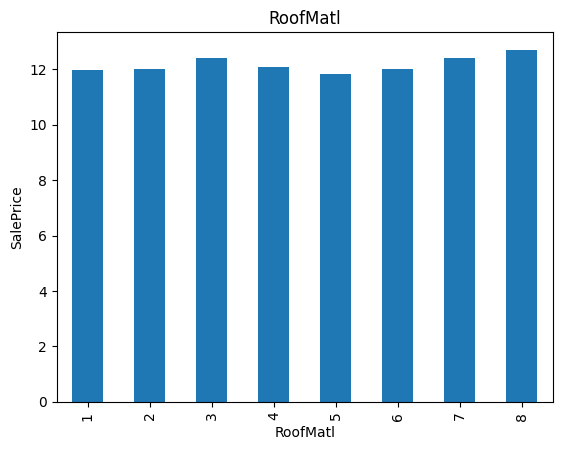

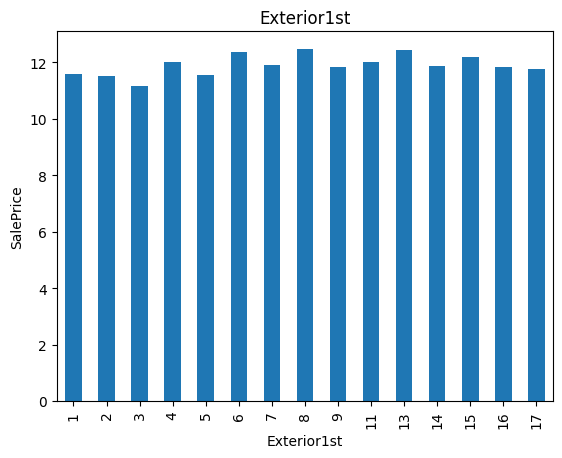

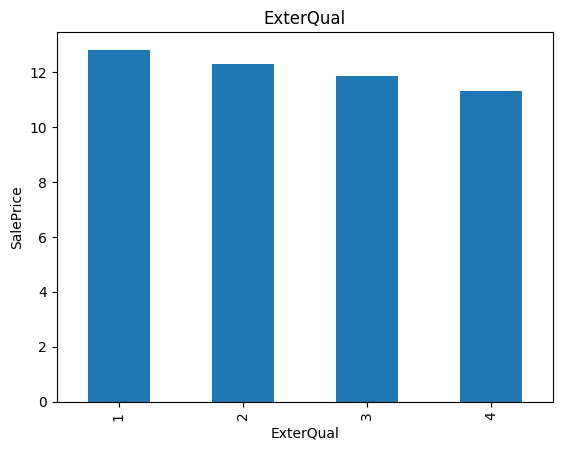

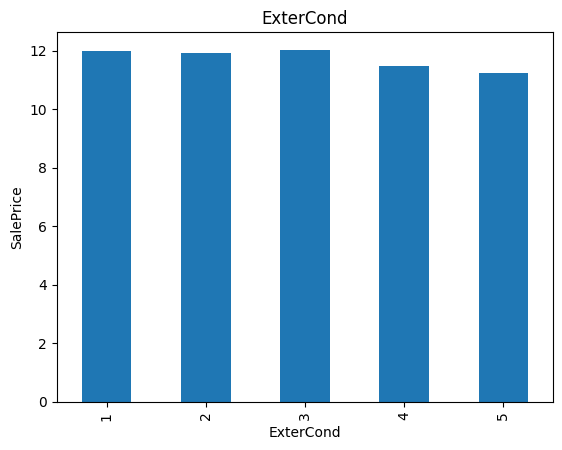

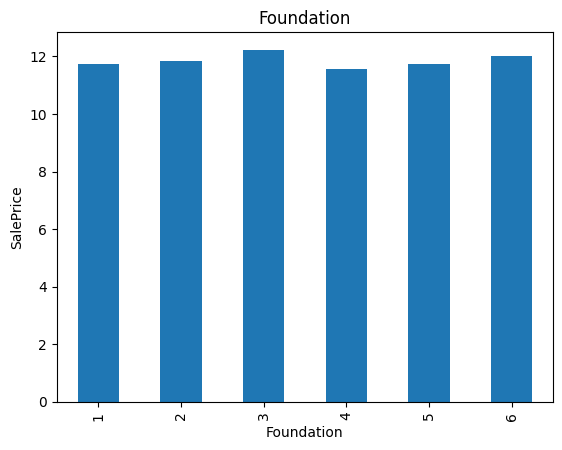

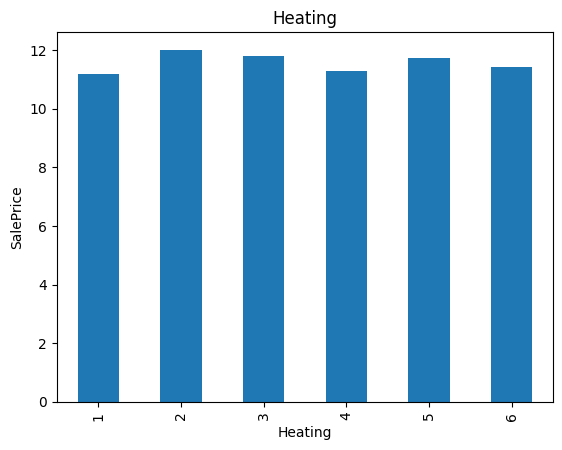

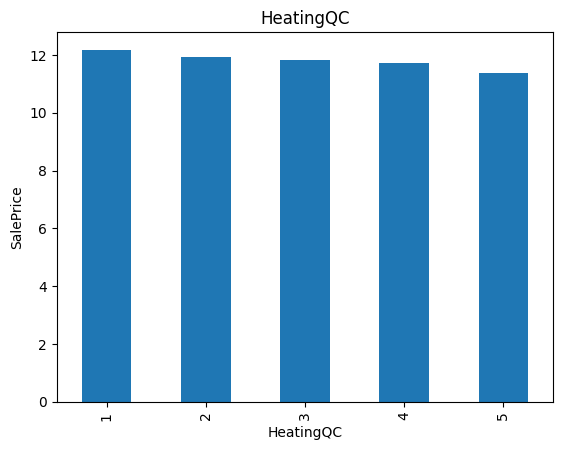

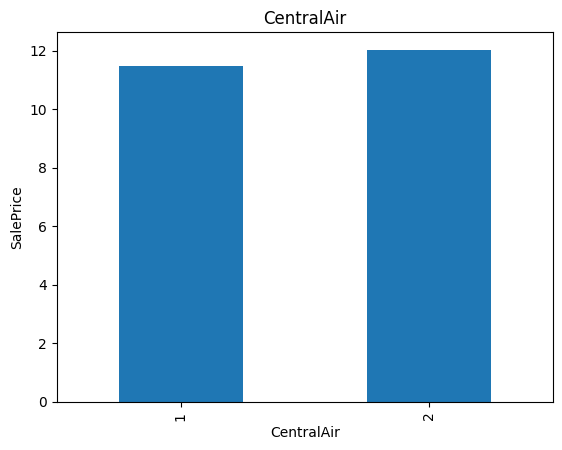

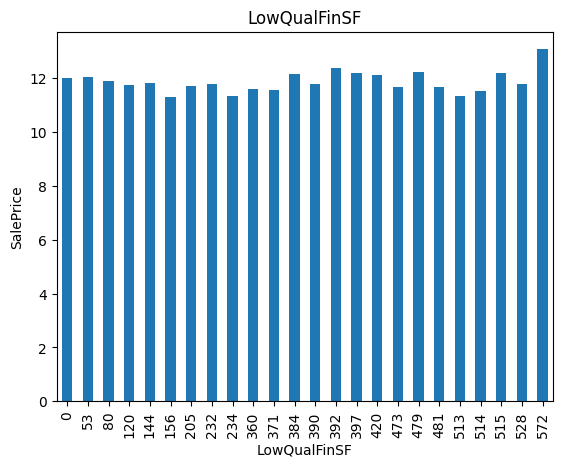

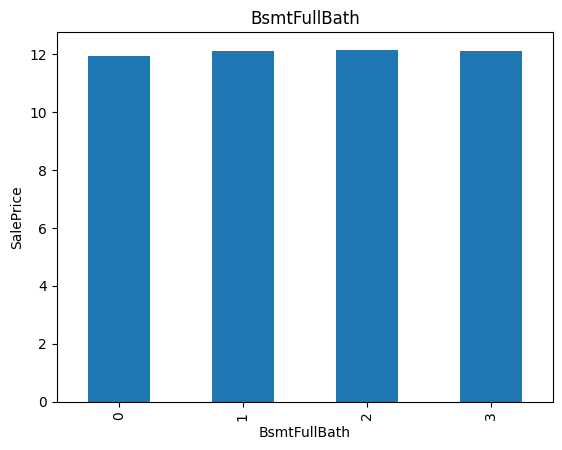

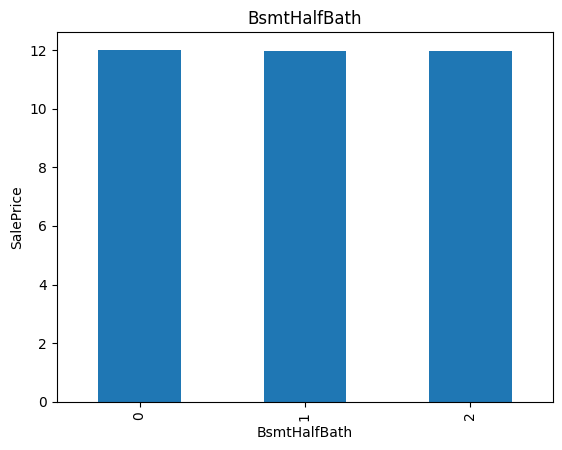

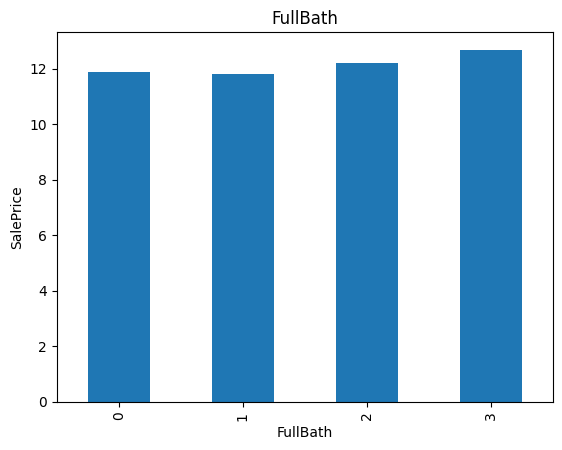

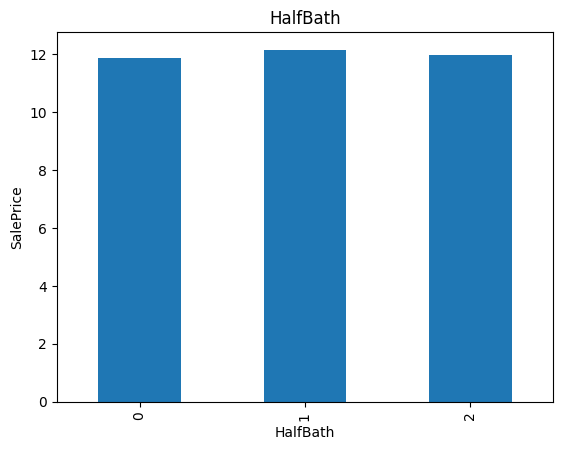

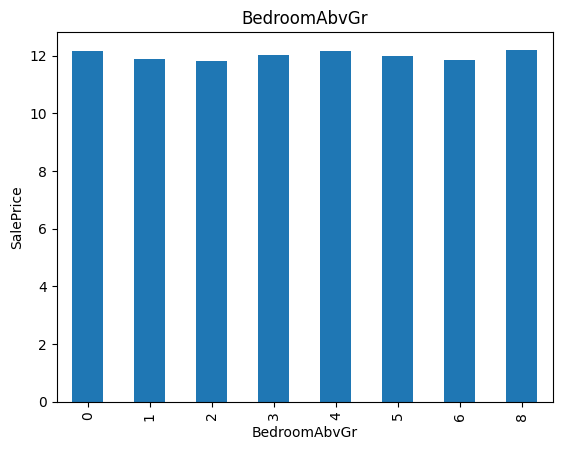

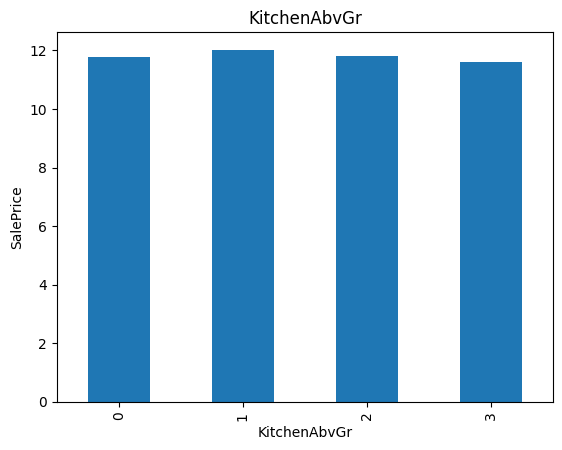

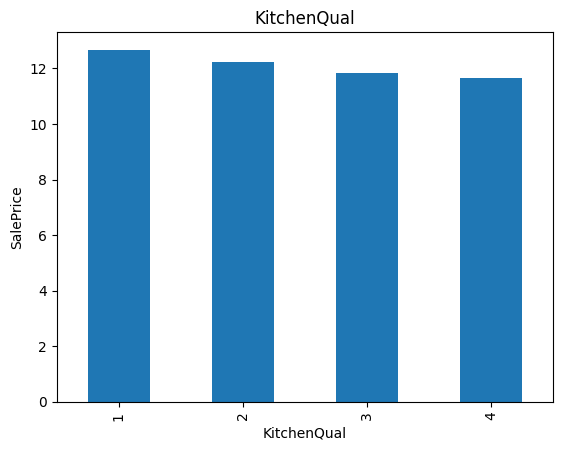

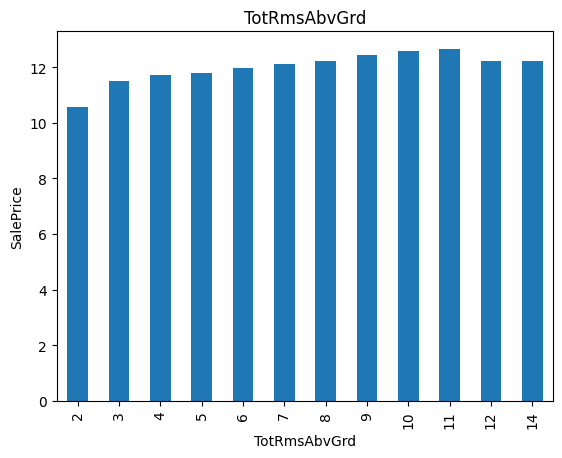

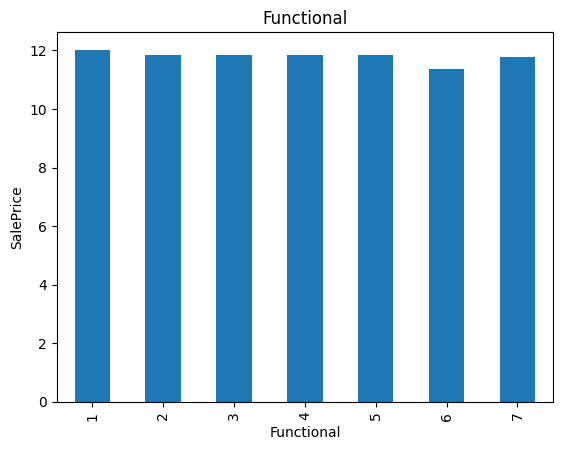

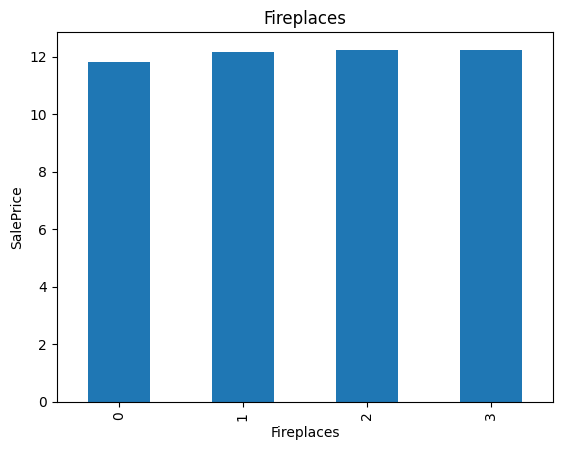

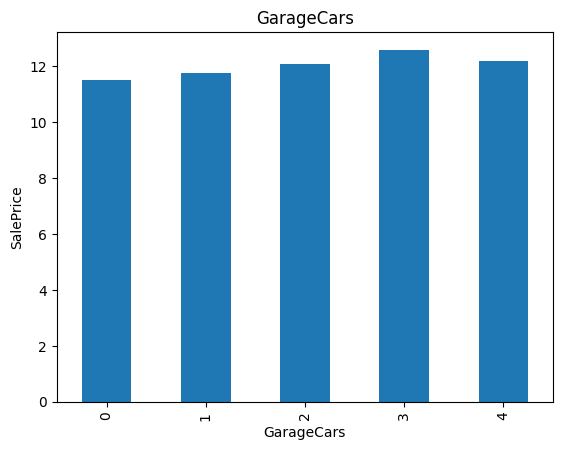

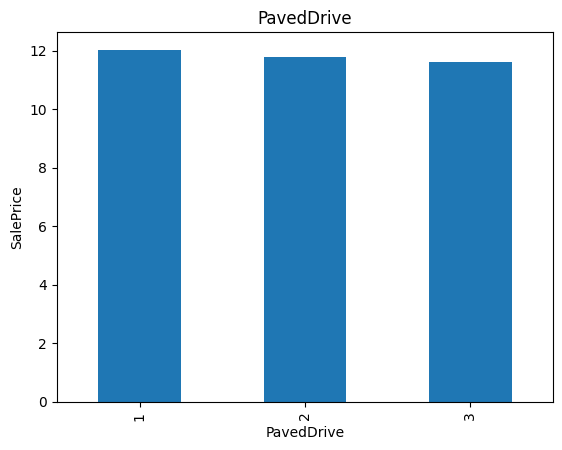

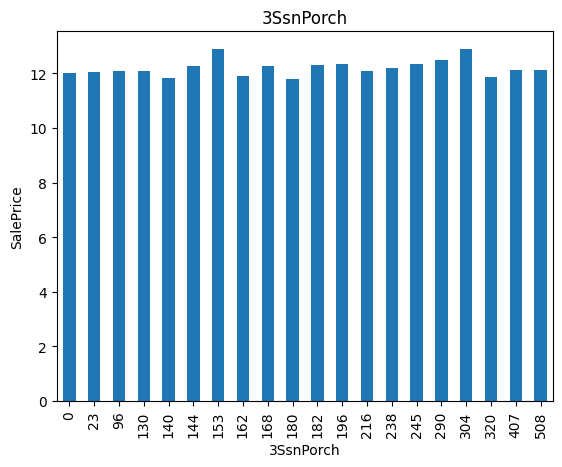

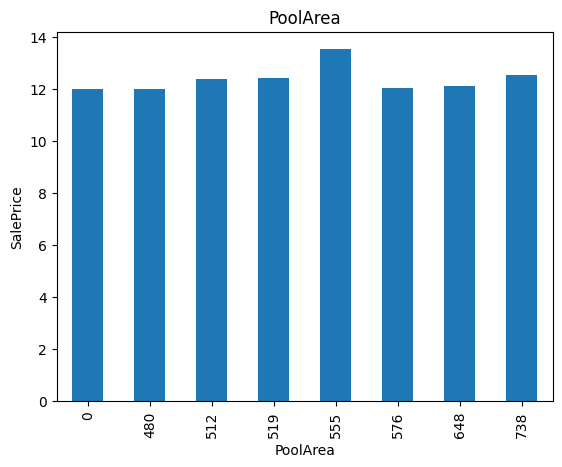

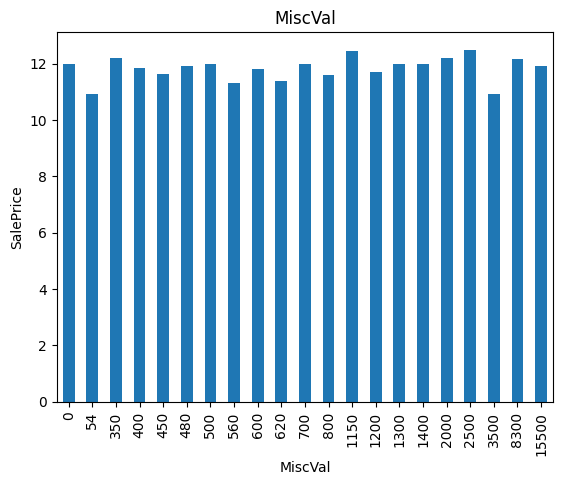

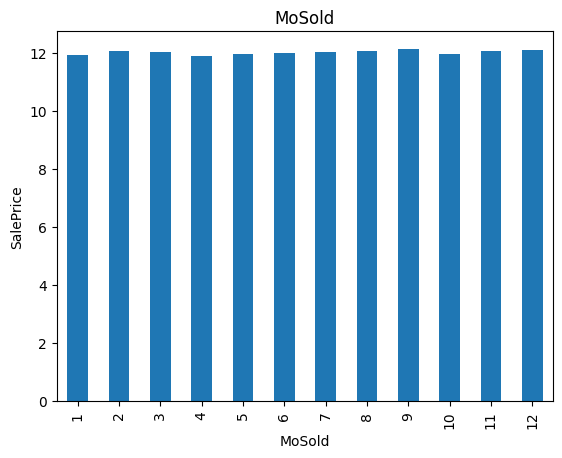

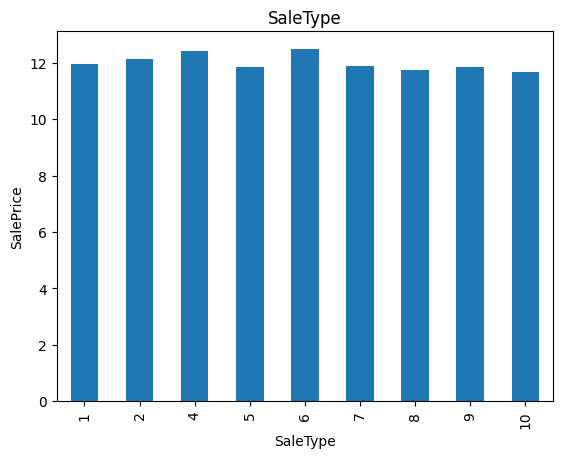

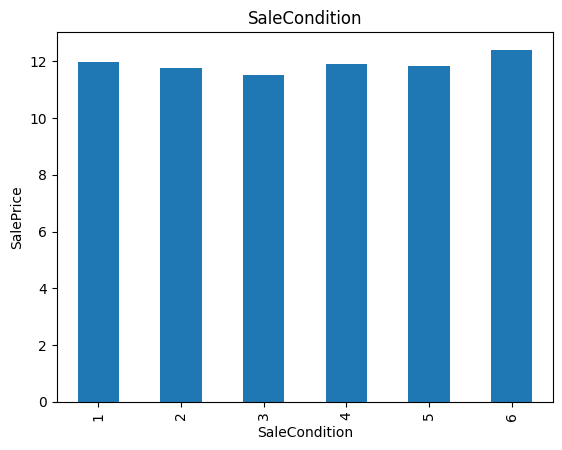

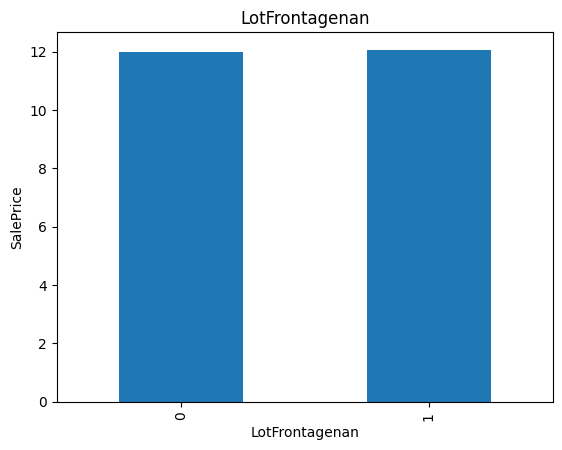

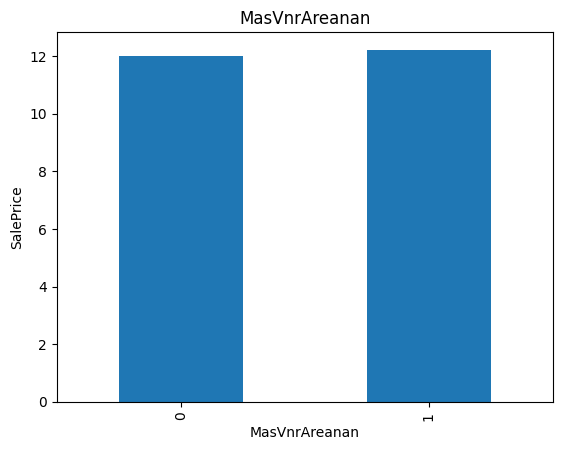

In [107]:
for feature in discrete_feature:
    data=data.copy()
    data.groupby(feature)['SalePrice'].median().plot.bar()
    plt.xlabel(feature)
    plt.ylabel('SalePrice')
    plt.title(feature)
    plt.show()
#There is a relationship between the number of discrete variables and the Sale Price after visualization.

Continuous Variable

In [108]:
continuous_feature=[feature for feature in numerical_features if feature not in discrete_feature+year_feature+['Id']]
print("Continuous feature Count {}".format(len(continuous_feature)))

Continuous feature Count 16


To analyze the continuous data and comprehend the distribution, let's create histograms.

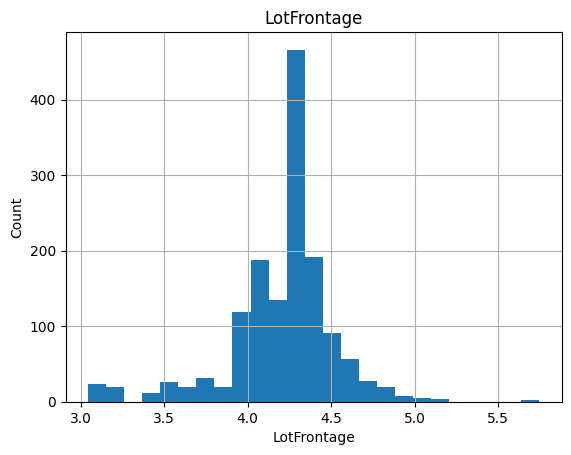

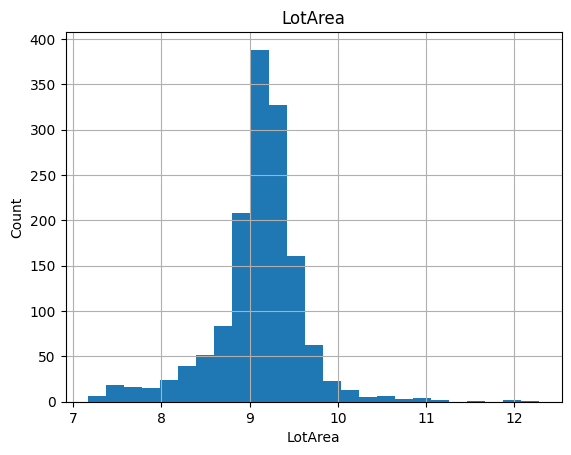

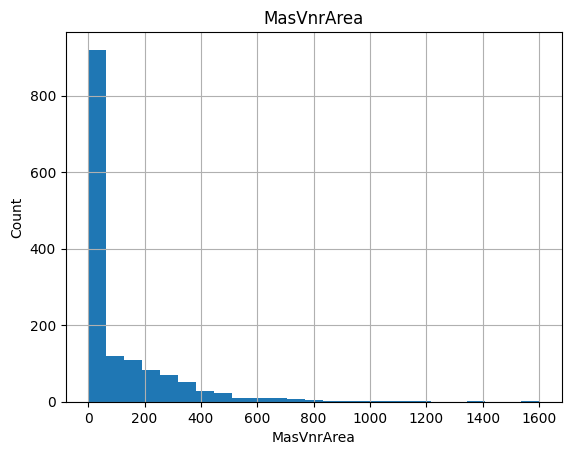

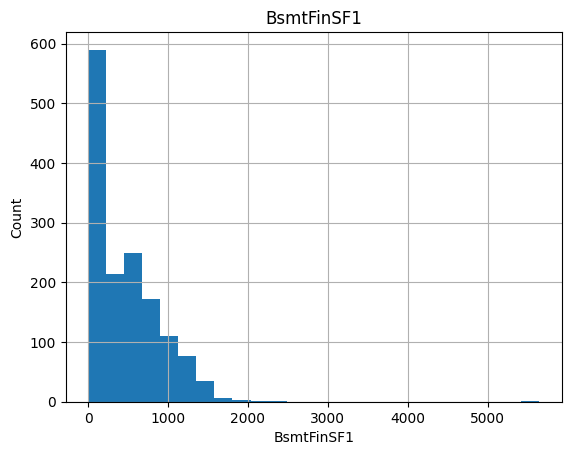

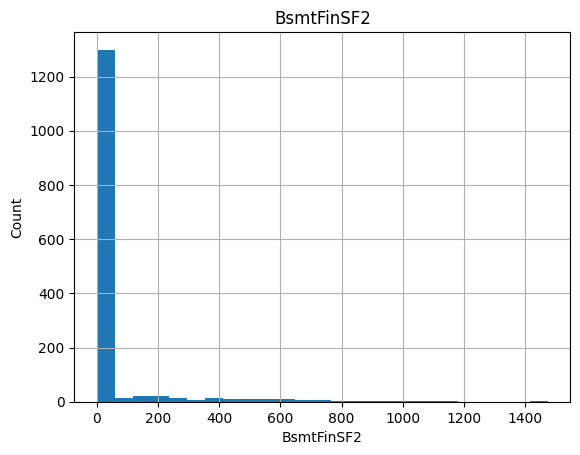

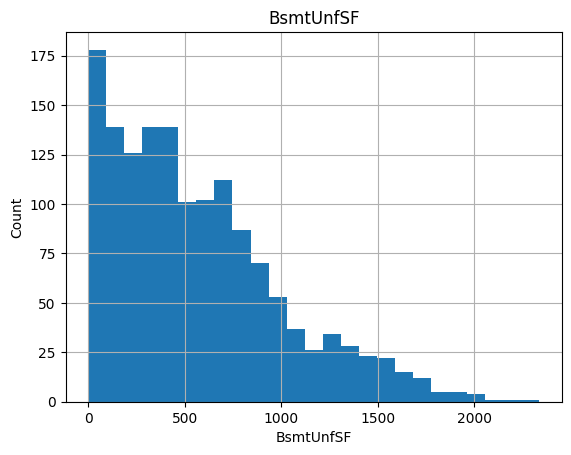

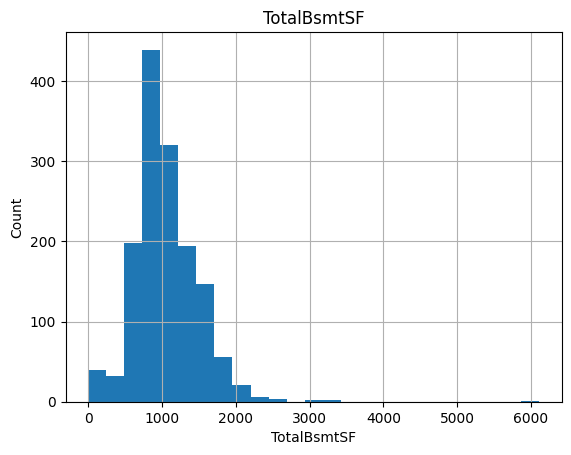

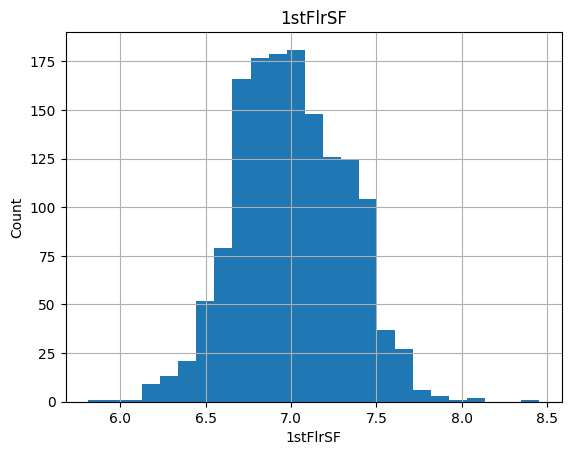

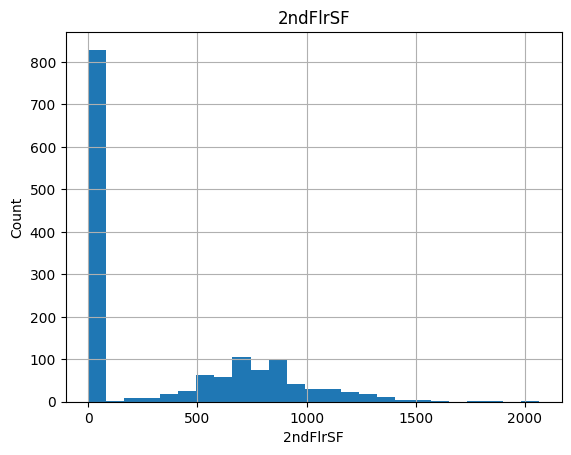

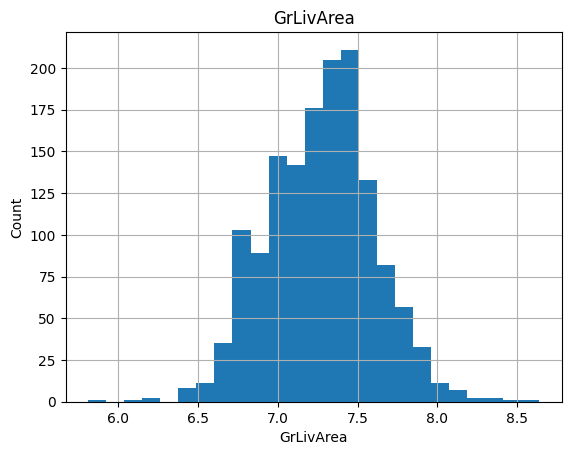

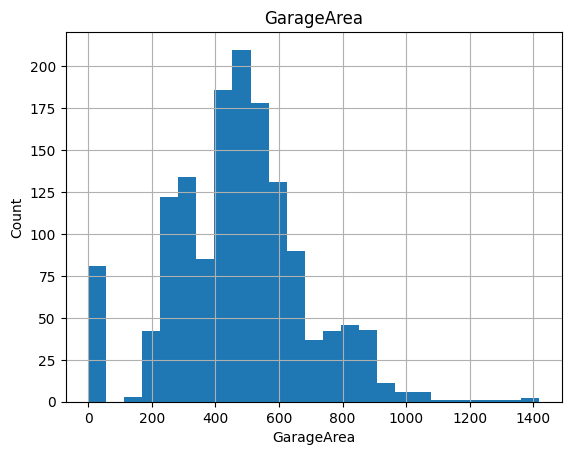

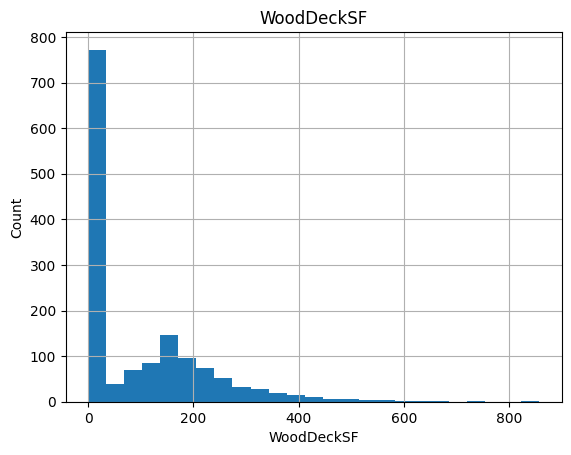

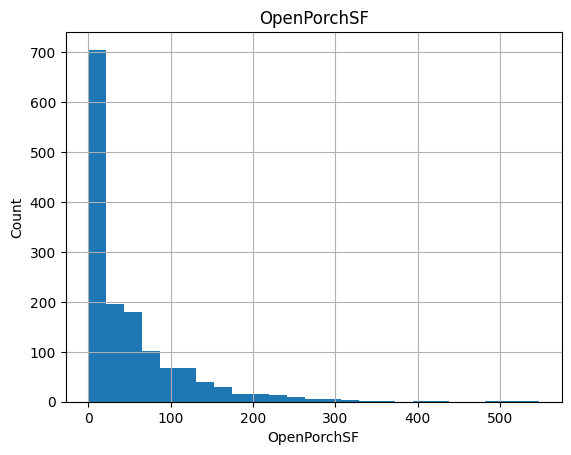

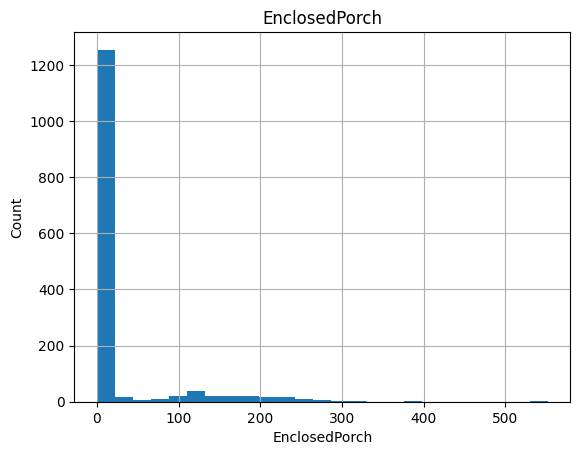

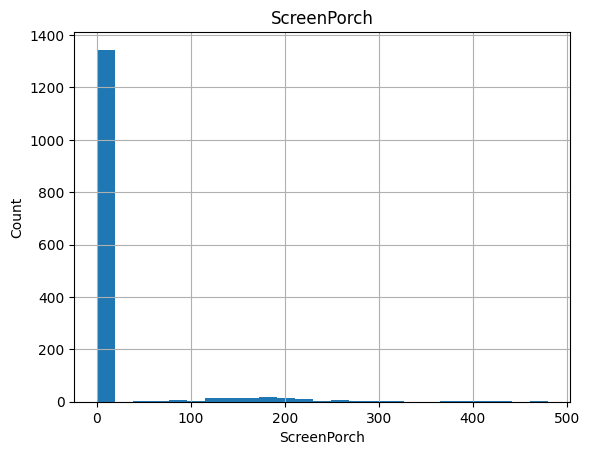

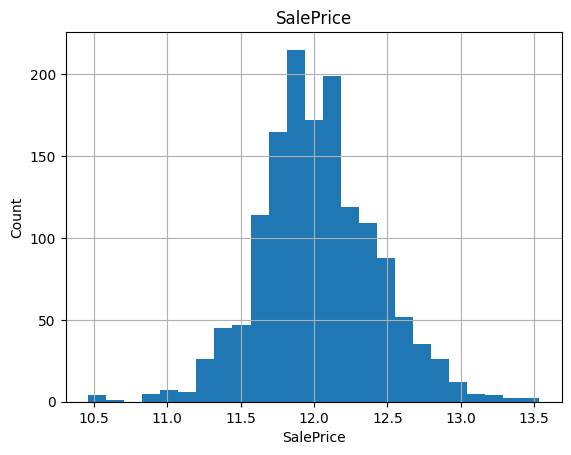

In [109]:
for feature in continuous_feature:
    data=data.copy()
    data[feature].hist(bins=25)
    plt.xlabel(feature)
    plt.ylabel("Count")
    plt.title(feature)
    plt.show()

Outliers

After pre-processing the data and processing it using the Log and Mean, we observe that the outlier rate is extremely low.

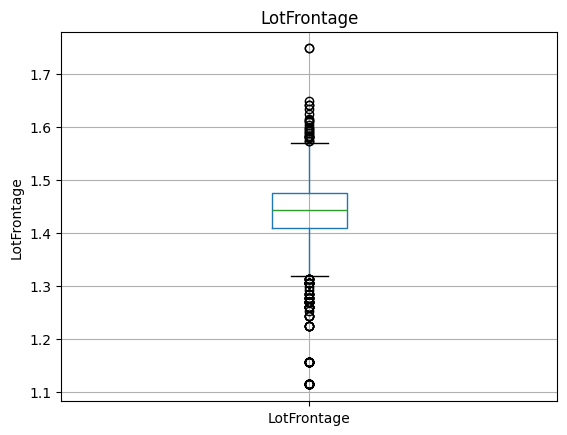

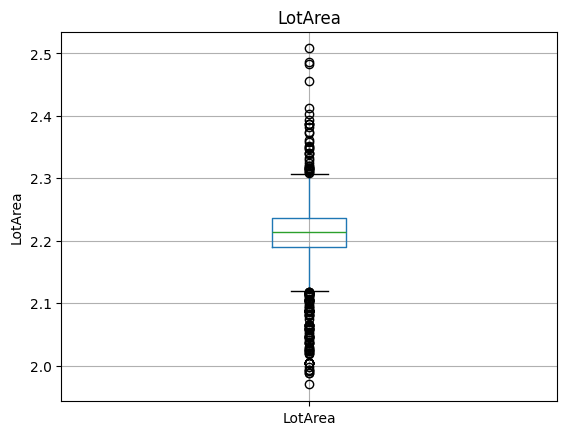

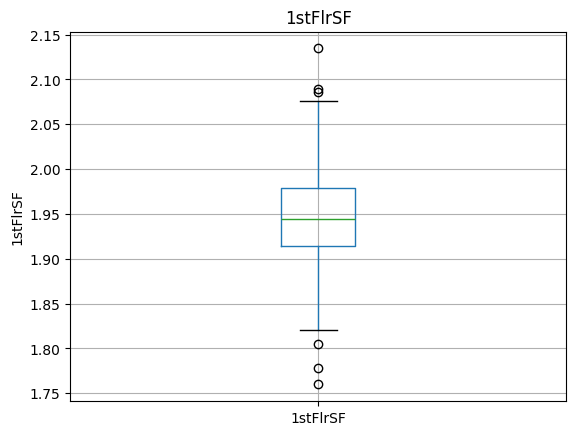

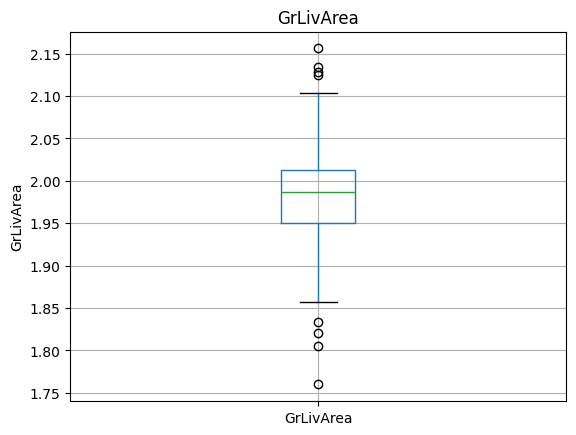

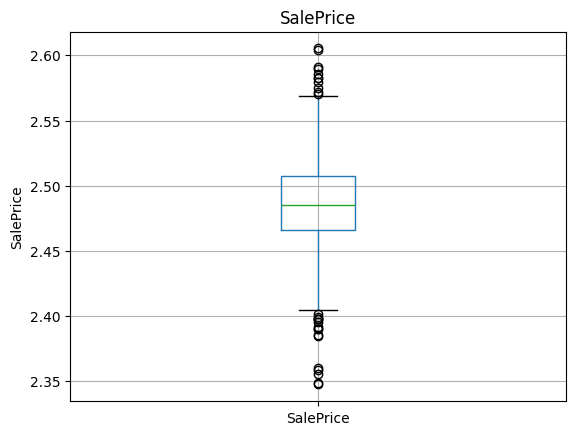

In [110]:
for feature in continuous_feature:
    data=data.copy()
    if 0 in data[feature].unique():
        pass
    else:
        data[feature]=np.log(data[feature])
        data.boxplot(column=feature)
        plt.ylabel(feature)
        plt.title(feature)
        plt.show()

Determine the relationship between each variable and the dependent feature Sales Price.

Data sets like GrLivArea, GarageCars, ExterQual, KitchenQual, GarageArea TotalBsmtSF, and 1stFIrSF have a high degree of dependency on SalePrice, whereas data sets like ID, Utilities, BsmtFinSF2, and BsmtHalfBath appear to have little relationship with SalePrice.

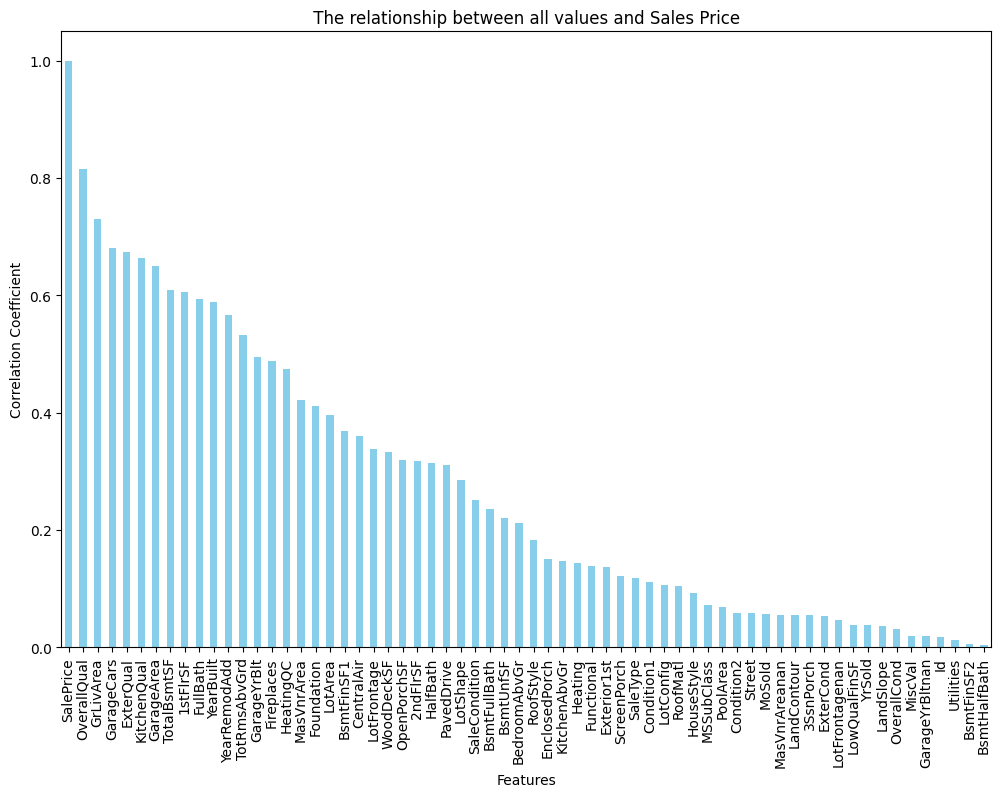

In [111]:
import pandas as pd
import matplotlib.pyplot as plt

correlation_matrix = data.corr()

# Extract correlation values related to 'SalesPrice'
sales_price_correlation = correlation_matrix['SalePrice']

# Sort the correlations in descending order to see the strongest relationships first
sorted_correlations = sales_price_correlation.abs().sort_values(ascending=False)

# Plotting
plt.figure(figsize=(12, 8))
sorted_correlations.plot(kind='bar', color='skyblue')
plt.title(' The relationship between all values and Sales Price ')
plt.xlabel('Features')
plt.ylabel('Correlation Coefficient')
plt.show()